# Taller ingeniería de datos

El problema que se desea resolver haciendo un modelo predictivo es el siguiente:

*En la industria de telecomunicaciones, la **retención de clientes** es uno de los mayores desafíos para las empresas, ya que la pérdida de clientes (churn) afecta directamente los ingresos y la sostenibilidad del negocio. En este contexto, la empresa que proporciona servicios de telecomunicaciones a través del dataset tiene como objetivo reducir la **tasa de cancelación de sus servicios**. En particular, la variable **Churn Label** identifica a aquellos clientes que han decidido abandonar el servicio. Para abordar este problema, es crucial predecir con antelación qué clientes podrían cancelar su suscripción, para implementar estrategias de retención específicas. Este análisis predictivo no solo ayudaría a identificar a los clientes en riesgo de churn, sino que también podría revelar factores determinantes como la **razón de cancelación**, **tipos de contrato**, **método de pago**, **tasa de uso** y otras variables que influyen en la decisión de los clientes. Por lo tanto, realizar un análisis predictivo basado en estas variables permitirá a la empresa tomar medidas proactivas para mejorar su **estrategia de fidelización** y, en última instancia, reducir el churn y aumentar la **rentabilidad** a largo plazo.*

El equipo de análisis cuenta con un dataset cuyo diccionario de datos se puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Cargue el archivo de datos, y haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

In [2]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("data")

file_path = "Telco_customer_churn.csv"

df = pd.read_csv(
    DATA_DIR / file_path,
    na_values=[' ?', ' ']
    )

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [4]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges          11
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [5]:
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  0


In [6]:
df.describe(include='object')

/var/folders/g0/r9m7njmn0m38dtqmkct459dm0000gn/T/ipykernel_7220/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,...,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Churn Label,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043,7043,1869
unique,7043,1,1,1129,1652,2,2,2,2,2,...,3,3,3,3,3,3,2,4,2,20
top,3668-QPYBK,United States,California,Los Angeles,"33.964131, -118.272783",Male,No,No,No,Yes,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,No,Attitude of support person
freq,1,7043,7043,305,5,3555,5901,3641,5416,6361,...,3088,3095,3473,2810,2785,3875,4171,2365,5174,192


## Análisis

En el dataset hay 7043 clientes y 33 variables que nos ayudarán a entender el comportamiento. No existen valores nulos en la mayoría de las variables, pero la variable Churn Reason si contiene 5174 valores nulos, esto no es un problema de calidad debido a que hay clientes los cuales no abandonaron el servicio por lo cual no necesitan una razón de cancelación ya que no aplica y no hay registros duplicados.

## Variables a descartar
- CustomerID: Es un identificador único, no aporta mucha información para la predicción
- Count: Todos tienen el mismo valor (1)
- Country: En el count sale 7043 y unique 1, por lo que todos pertenecen al mismo país
- State: En el count sale 7043 y unique 1, por lo que todos pertenecen al mismo estado
- Lat Long: Redunda con las variables Latitude y Longitud pero juntas en una sola cadena de texto
- Churn Value: Redunda con Churn Label pero lo da en números (int)
- Churn Score_ Podría haber filración de datos ya que es la puntuación que se calcula y podría dar información al modelo que se va a contruir con resultados ya predecidos
- Churn Reason: Puede haber filtración de datos ya que la razón de la cancelación se hace cuando el cliente abandono el servicio y el modelo busca es predecir el "Churn"
-Zip Code: Redundancia geográfica

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.

Reporte los resultados del análisis en una celda de texto.

In [7]:
columns_to_drop = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'Lat Long',
    'Churn Value',
    'Churn Score',
    'Churn Reason',
    'Zip Code'
]

df_edit = df.drop(columns=columns_to_drop)

df_edit.head()

,City,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,CLTV
0,Los Angeles,33.964131,-118.272783,Male,No,No,No,2,Yes,No,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3239
1,Los Angeles,34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2701
2,Los Angeles,34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,5372
3,Los Angeles,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,5003
4,Los Angeles,34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,5340


In [8]:
df_edit.select_dtypes(include='object').nunique()

/var/folders/g0/r9m7njmn0m38dtqmkct459dm0000gn/T/ipykernel_7220/951717685.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_edit.select_dtypes(include='object').nunique()


City                 1129
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Churn Label             2
dtype: int64

In [9]:
for col in df_edit.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df_edit[col].unique())


City:
<StringArray>
[    'Los Angeles',   'Beverly Hills', 'Huntington Park',         'Lynwood',
  'Marina Del Rey',       'Inglewood',    'Santa Monica',        'Torrance',
        'Whittier',        'La Habra',
 ...
      'Janesville',      'Litchfield',        'Loyalton',        'Madeline',
    'Markleeville',         'Milford',         'Calpine',        'Standish',
        'Tulelake',  'Olympic Valley']
Length: 1129, dtype: str

Gender:
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

Senior Citizen:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Partner:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Dependents:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Phone Service:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Multiple Lines:
<StringArray>
['No', 'Yes', 'No phone service']
Length: 3, dtype: str

Internet Service:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

Online Security:
<StringArray>
['Yes', 'No', 'No internet service']
Len

/var/folders/g0/r9m7njmn0m38dtqmkct459dm0000gn/T/ipykernel_7220/1770422732.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_edit.select_dtypes(include='object').columns:


- De las variables no descartadas se puede decir que las variables nominales son City, Payment Method, Streaming Movies, Online Backup, Internet Service, Online Security, Tech Support, Streaming TV, Device Protection, Multiple Lines, Gender, Dependents, Phone Service, Senior Citizen, Partner y Paperless Billing, ya que no tienen un orden o jerarquía inherente entre sí
- La variable ordinal es Contract ya que tiene una jerarquía ('Month-to-month' -> 'One year' -> 'Two year')
- La variable con alata cardinalidad es City, la cual tiene una gran cantidad de valores únicos (1129 categorías)

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Reporte los resultados del análisis en una celda de texto.

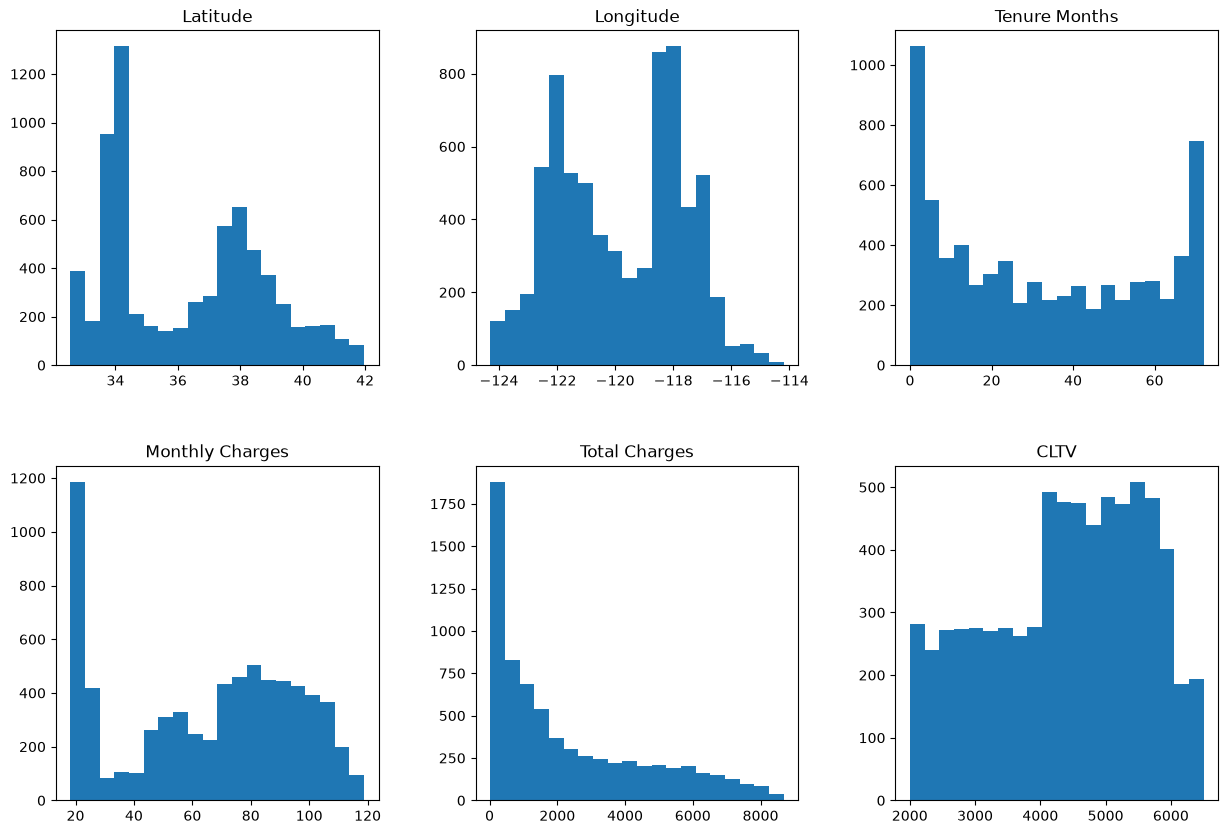

In [10]:
df_edit.select_dtypes('number').hist(bins=20, figsize=(15,10), grid=False, layout=(2,3));

       Tenure Months  Monthly Charges  Total Charges     Latitude    Longitude
count    7043.000000      7043.000000    7032.000000  7043.000000  7043.000000
mean       32.371149        64.761692    2283.300441    36.282441  -119.798880
std        24.559481        30.090047    2266.771362     2.455723     2.157889
min         0.000000        18.250000      18.800000    32.555828  -124.301372
25%         9.000000        35.500000     401.450000    34.030915  -121.815412
50%        29.000000        70.350000    1397.475000    36.391777  -119.730885
75%        55.000000        89.850000    3794.737500    38.224869  -118.043237
max        72.000000       118.750000    8684.800000    41.962127  -114.192901

Asimetría (skew):
Tenure Months      0.239540
Monthly Charges   -0.220524
Total Charges      0.961642
Latitude           0.303867
Longitude         -0.040792
dtype: float64


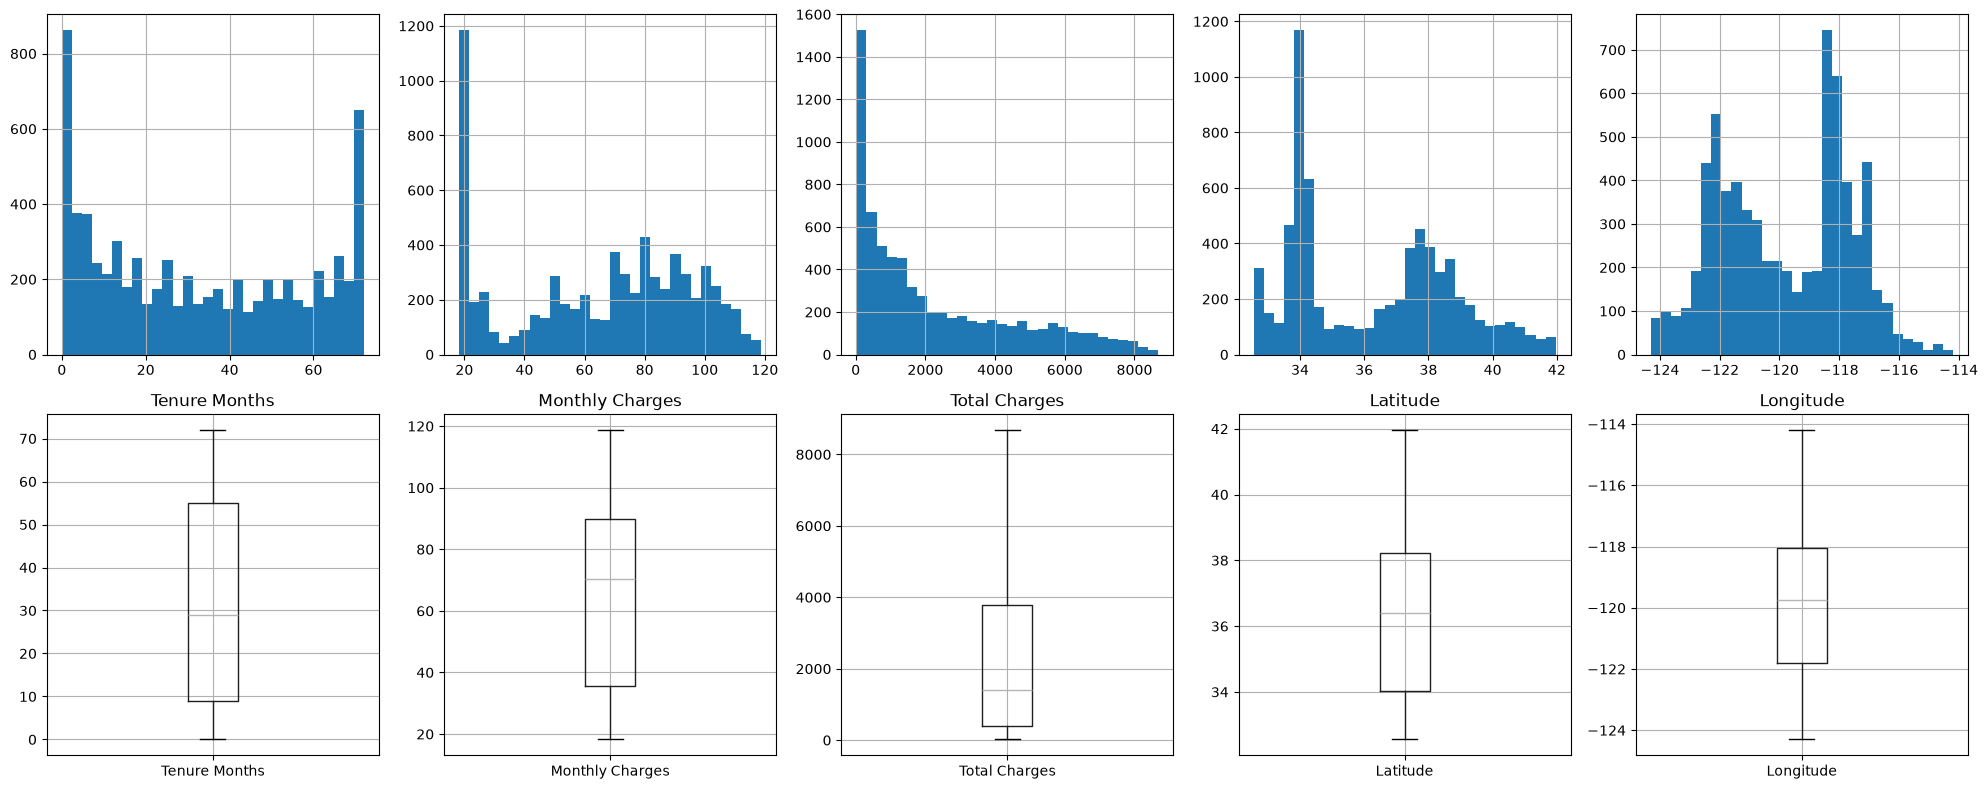

In [11]:
import matplotlib.pyplot as plt

df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

quant_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Latitude', 'Longitude']

print(df[quant_cols].describe())
print('\nAsimetría (skew):')
print(df[quant_cols].skew())

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, col in enumerate(quant_cols):
    df[col].hist(bins=30, ax=axes[0, i])
    df.boxplot(column=col, ax=axes[1, i])
    axes[1, i].set_title(f'{col}')
plt.tight_layout()
plt.show()

#### Podemos observar por medio de las gráficas presentadas (Histogramas, boxplots) el siguiente análisis:
- Tenure Months: es bimodal, con un pico grande en 0 (clientes nuevos) y otro en 70 (clientes con más antigüedad)
- Monthly Charges: Es multimodal, con un pico marcado cerca de 20 (esto debido a que probablemente son clientes que solo tienen un servicio básico) y luego una distribución más dispersa entre 60-100
- Total Charges: es unimodal pero con sesgo fuerte a la derecha (cola larga), consistente con el skew que observamos de 0.96 que calculamos.
- Latitude y Longitude: son claramente bimodales, con dos picos de concentración, esto refleja que los clientes se agrupan geográficamente en un par de zonas de California

Además podemos ver que en ninguna de las variables analizadas encontramos valores atípicos

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Churn Label**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 6 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 6 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión logística. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Matriz
X = df_edit.drop(['Churn Label'], axis=1)
y = df_edit['Churn Label']

# Particionando los datos 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.8)

print(f'Tamaño del conjunto de entrenamiento: {X_train.shape}')
print(f'Tamaño del conjunto de prueba: {X_test.shape}')

# transformadores
ss = StandardScaler()  # Para Tenure Months y Monthly Charges

orden_contrato = ['Month-to-month', 'One year', 'Two year']
ore = OrdinalEncoder(categories=[orden_contrato], dtype='int')  # Contract

ohe = OneHotEncoder(sparse_output=False, drop='if_binary')  # nominales

# pre procesamiento
preprocessor = ColumnTransformer(transformers=[
    ('tenure_monthly', ss, ['Tenure Months', 'Monthly Charges']),
    ('contract', ore, ['Contract']),
    ('internet_payment_senior', ohe, ['Internet Service', 'Payment Method', 'Senior Citizen'])
    ],
    remainder='drop')

# flujo integrado
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=10000))
    ])

# entrenamiento
pipeline.fit(X_train, y_train)

print(f'Exactitud en entrenamiento: {pipeline.score(X_train, y_train)}')
print(f'Exactitud en prueba: {pipeline.score(X_test, y_test)}')

pipeline.named_steps['preprocessor'].get_feature_names_out()

Tamaño del conjunto de entrenamiento: (5634, 23)
Tamaño del conjunto de prueba: (1409, 23)
Exactitud en entrenamiento: 0.7937522186723465
Exactitud en prueba: 0.7927608232789212


array(['tenure_monthly__Tenure Months', 'tenure_monthly__Monthly Charges',
       'contract__Contract',
       'internet_payment_senior__Internet Service_DSL',
       'internet_payment_senior__Internet Service_Fiber optic',
       'internet_payment_senior__Internet Service_No',
       'internet_payment_senior__Payment Method_Bank transfer (automatic)',
       'internet_payment_senior__Payment Method_Credit card (automatic)',
       'internet_payment_senior__Payment Method_Electronic check',
       'internet_payment_senior__Payment Method_Mailed check',
       'internet_payment_senior__Senior Citizen_Yes'], dtype=object)

### Análisis
Tras el procesamiento resultaron en 11 columnas finales. Obtuvimos una exactitud de 0.7938 en entrenamiento y 0.7928 en la de prueba, como los valores son muy cercanos entre sí, indican que el modelo generaliza bien y no presenta sobreajuste, aunque el nivel de exactitud en sí es moderado 79%, ya que estas 6 variables básicas capturan patrones generales de churn pero dejan fuera aspectos como los servicios adicionales contratados, que suelen influir bastante en la decisión de cancelar.

Vuelva a entrenar el modelo, pero esta vez añada 3 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [13]:
from sklearn.preprocessing import PowerTransformer
from sklearn.impute import SimpleImputer

total_charges_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('power', PowerTransformer())
])

preprocessor = ColumnTransformer(transformers=[
    ('tenure_monthly', ss, ['Tenure Months', 'Monthly Charges']),
    ('total_charges', total_charges_pipe, ['Total Charges']),
    ('contract', ore, ['Contract']),
    ('nominales', ohe, ['Internet Service', 'Payment Method', 'Senior Citizen', 'Tech Support', 'Paperless Billing'])
    ],
    remainder='drop')

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=10000))
    ])

pipeline.fit(X_train, y_train)

print(f'Exactitud en entrenamiento: {pipeline.score(X_train, y_train)}')
print(f'Exactitud en prueba: {pipeline.score(X_test, y_test)}')

pipeline.named_steps['preprocessor'].get_feature_names_out()

Exactitud en entrenamiento: 0.8022719204827831
Exactitud en prueba: 0.8069552874378992


array(['tenure_monthly__Tenure Months', 'tenure_monthly__Monthly Charges',
       'total_charges__Total Charges', 'contract__Contract',
       'nominales__Internet Service_DSL',
       'nominales__Internet Service_Fiber optic',
       'nominales__Internet Service_No',
       'nominales__Payment Method_Bank transfer (automatic)',
       'nominales__Payment Method_Credit card (automatic)',
       'nominales__Payment Method_Electronic check',
       'nominales__Payment Method_Mailed check',
       'nominales__Senior Citizen_Yes', 'nominales__Tech Support_No',
       'nominales__Tech Support_No internet service',
       'nominales__Tech Support_Yes', 'nominales__Paperless Billing_Yes'],
      dtype=object)

### Análisis
Se le agregaron Total Charges (aplicando PowerTransformer para corregir su sesgo), Tech Support y Paperless Billing, quedando entrenado con 16 columnas resultantes del procesamiento. La exactitud subió a 0.8023 en entrenamiento y 0.8070 en prueba, mejorando cerca de un punto porcentual respecto al modelo anterior y manteniendo los dos scores muy parejos, lo que confirma que el modelo sigue sin sobreajustarse. Esta mejora sugiere que el gasto acumulado del cliente y la contratación de servicios como soporte técnico y facturación sin papel aportan información adicional relevante para predecir el churn, validando la hipótesis planteada en el análisis exploratorio inicial.